# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [55]:
medical.shape

(1338, 8)

In [56]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__ The histogram shows that medical charges are highly right-skewed with a long tail extending toward higher values. 

**Mean and Standard Deviation Appropriateness:**
- The mean (≈$13,270) is pulled upward by the extreme high values, making it higher than what most patients actually pay.
- The standard deviation (≈$12,110) is large relative to the mean, indicating high variability.
- For this skewed distribution, the median and interquartile range (IQR) would be better descriptors of "typical" patient charges, as they're less affected by extreme values.
- However, the mean and standard deviation are still valid and essential despite the skewness. They are needed to capture total revenue impact, and the Central Limit Theorem assures us that the sampling distribution of the sample mean will approach normality as sample size increases. With our extremely large sample size of n=1338, this allows us to make valid inferences about the population mean.

Text(0, 0.5, 'Number of patients')

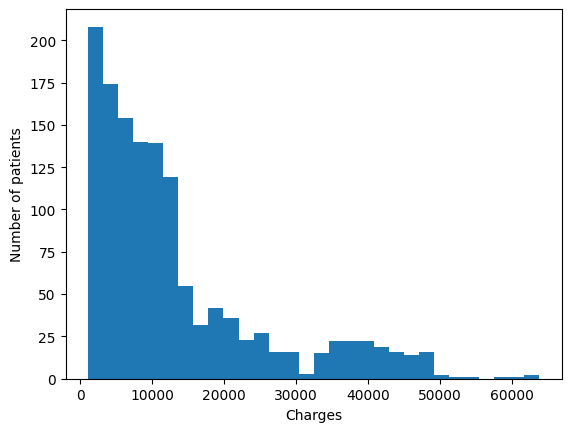

In [57]:
plt.hist(medical['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Number of patients')

In [58]:
mean_charges = np.mean(medical['charges'])
print(f'mean_charges: {mean_charges:<.2f}')

mean_charges: 13270.42


In [59]:
std_charges = np.std(medical['charges'], ddof=1)
print(f'std_charges: {std_charges:<.2f}')

std_charges: 12110.01


__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ \
**Justification for using these data:**
These data represent a random sample from the hospital, and we know from the Central Limit Theorem that the sampling distribution of the sample mean will be approximately normal despite the skewed population distribution, especially since the sample size(n=1338) is very large. This allows us to make valid inferences about the population mean even though individual charges are not normally distributed.

**Most appropriate frequentist test:**
A one-sample t-test is most appropriate here:
- "One-sample" because we're testing whether the population mean μ differs from a specific value ($12,000)
- "t-test" because we use the t-distribution rather than z-distribution when σ (population standard deviation) is unknown

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ The administrator is only concerned about whether the mean charges are < $12,000, not whether the charges are different from $12,000. Therefore, a one-sided (lower tail) 95% confidence interval is appropriate for this situation.

**Confidence Interval Approach:**
- We calculate a one-sided confidence interval to find the lower bound.
- This tells us we are 95% confident the true population mean is above this lower bound.
- If the lower bound ≥ $12,000, then we can be confident the mean is above $12,000, and the administrator should not be concerned

**Results:**
Our calculations show the lower bound of the 95% confidence interval is $12,725.49.

**Conclusion:** Since $12,725.49 > $12,000, we are 95% confident that the true population mean is above the administrator's threshold of $12,000. Therefore, the administrator should not be concerned about revenue falling below the operational threshold.

In [60]:
critical_t_value = t.ppf(0.95, df=len(medical)-1)
print(f'critical_t_value: {critical_t_value:<.2f}')

standard_error = std_charges / np.sqrt(len(medical))
print(f'standard_error: {standard_error:<.2f}')

margin_of_error = critical_t_value * standard_error
print(f'margin_of_error: {margin_of_error:<.2f}')

critical_t_value: 1.65
standard_error: 331.07
margin_of_error: 544.94


In [61]:
lower_ci = mean_charges - margin_of_error
print(f'lower confidence interval: ${lower_ci:<.2f}')


lower confidence interval: $12725.49


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__
**Hypotheses for comparing insured vs. uninsured patients:**
- **Null Hypothesis (H₀):** There is no difference in mean charges between insured and uninsured patients (μ₁ = μ₀)
- **Alternative Hypothesis (H₁):** There is a difference in mean charges between insured and uninsured patients (μ₁ ≠ μ₀)

Where μ₁ = mean charges for insured patients and μ₀ = mean charges for uninsured patients.

**Assumption about variances:** 
By using the pooled standard deviation formula, we assume that the two groups (insured vs. uninsured) have equal population variances (σ₁² = σ₀²). This is the assumption of homogeneity of variance or homoscedasticity.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ I got the same results from both methods:\
**Comparison of Manual vs Scipy Results**
Manual t_statistic: 11.89\
Scipy t_statistic:  11.89\
Difference in t-stat: 0.0000000000

Manual p_value: 0.0000000000\
Scipy p_value:  0.0000000000\
Difference in p-value: 0.0000000000

In [62]:
with_insurance = medical[medical['insuranceclaim'] == 1]['charges']
print("With Insurance:")
print(with_insurance.describe(),'\n')

without_insurance = medical[medical['insuranceclaim'] == 0]['charges']
print("Without Insurance:")
print(without_insurance.describe())

std_with_insurance = np.std(medical[medical['insuranceclaim'] == 1]['charges'], ddof=1)

std_without_insurance = np.std(medical[medical['insuranceclaim'] == 0]['charges'], ddof=1)

n_with_insurance = len(medical[medical['insuranceclaim'] == 1]['charges'])
print(f'n_with_insurance: {n_with_insurance}')

n_without_insurance = len(medical[medical['insuranceclaim'] == 0]['charges'])
print(f'n_without_insurance: {n_without_insurance}')

pooled_std = np.sqrt(((n_with_insurance - 1) * std_with_insurance**2 + (n_without_insurance - 1) * std_without_insurance**2) / (n_with_insurance + n_without_insurance - 2))
print(f'pooled_std: {pooled_std:<.2f}')


With Insurance:
count      783.000000
mean     16423.928277
std      14045.928419
min       1131.506600
25%       5733.288925
50%      11538.421000
75%      23484.788875
max      63770.428010
Name: charges, dtype: float64 

Without Insurance:
count      555.000000
mean      8821.421892
std       6446.510127
min       1121.873900
25%       4445.337575
50%       6933.242250
75%      11424.211575
max      36910.608030
Name: charges, dtype: float64
n_with_insurance: 783
n_without_insurance: 555
pooled_std: 11520.03


In [63]:
t_statistic = (np.mean(with_insurance) - np.mean(without_insurance)) / (pooled_std * np.sqrt(1/n_with_insurance + 1/n_without_insurance))

print(f't_statistic: {t_statistic:<.2f}')

t_statistic: 11.89



In [64]:
# Calculate degrees of freedom
degrees_of_freedom = n_with_insurance + n_without_insurance - 2
print(f'degrees_of_freedom: {degrees_of_freedom}')

# Calculate p-value for two-sided test (H1: μ₁ ≠ μ₀)--requires calculating both tails
p_value_two_sided = 2 * (1 - t.cdf(abs(t_statistic), df=degrees_of_freedom))
print(f'p_value (two-sided): {p_value_two_sided:.10f}')


degrees_of_freedom: 1336
p_value (two-sided): 0.0000000000


In [67]:
# Verify results using scipy.stats.ttest_ind
from scipy.stats import ttest_ind

# Perform two-sample t-test with equal variances (pooled)
t_stat_scipy, p_value_scipy = ttest_ind(with_insurance, without_insurance, equal_var=True)

print("=== scipy.stats Results ===")
print(f'scipy t_statistic: {t_stat_scipy:<.2f}')
print(f'scipy p_value: {p_value_scipy:.10f}')

print("\n=== Comparison of Manual vs Scipy Results ===")
print(f'Manual t_statistic: {t_statistic:<.2f}')
print(f'Scipy t_statistic:  {t_stat_scipy:<.2f}')
print(f'Difference in t-stat: {abs(t_statistic - t_stat_scipy):.10f}')

print(f'\nManual p_value: {p_value_two_sided:.10f}')
print(f'Scipy p_value:  {p_value_scipy:.10f}')
print(f'Difference in p-value: {abs(p_value_two_sided - p_value_scipy):.10f}')

=== scipy.stats Results ===
scipy t_statistic: 11.89
scipy p_value: 0.0000000000

=== Comparison of Manual vs Scipy Results ===
Manual t_statistic: 11.89
Scipy t_statistic:  11.89
Difference in t-stat: 0.0000000000

Manual p_value: 0.0000000000
Scipy p_value:  0.0000000000
Difference in p-value: 0.0000000000


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ No, I don't see an equivalent z-test function in scipy.stats for sample data.

This is because z-tests need you to know the population standard deviation (σ), but in reality we almost never know σ. When working with data from samples, we have to estimate the standard deviation from our sample, which adds uncertainty.

The t-test handles uncertainty by using the t-distribution instead of the normal distribution. The t-distribution has "fatter tails" to account for the uncertainty about our standard deviation estimate.

"scipy.stats.norm" can be used to perform a z-test manually if you know σ

Basically, since we almost always have to estimate σ from our sample data, t-tests are what we typically need in practice. Even with large sample sizes like ours (n=1338), the t-test is appropriate because we're estimating the population standard deviation from the sample.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test